In [98]:
from sklearn.linear_model import (
    LinearRegression,
    Lasso,
    ElasticNet
)

from sklearn.tree      import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm       import SVR

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor
)

from sklearn.neural_network import MLPRegressor

# Para analise de dados e a avaliacao de modelos
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    GridSearchCV,
)

from sklearn.feature_selection import (
    SelectKBest,
    chi2, f_regression
)

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sktime.regression.interval_based import TimeSeriesForestRegressor

# RNA
import tensorflow as tf
import keras

In [99]:
import numpy as np
import pandas as pd
import pandas_datareader.data as web

import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

from pandas.plotting import scatter_matrix
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima_model import ARIMA
import yfinance as yf

## Previsão da curva de termo(YIELD Curve)

Uma yield curve é uma linha que plota a taxas de juros de titulos que possuem uma mesma qualidade de crédito, mas diferentes datas de vencimento. Ela é usada como um benchmark para outras dividas no mercado , como taxa de financiamento imobiliario ou emprestismo bancarios.

> É a peça central em uma mercado de renda fixa.

A curva de termo0 é uma representação fundamental do estado do mercado de titulos. Pois é uma **forte preditor  da atividade economica futura e dos niveis de inflacionarios, que afetam os preço dos produtos, ativos financeiro e imoveis**

O Declive da taxa de juroos( yield) é crucial para aplicações financeiras.

### Definição do problema

Usaremos 3 prazos de 1 mes 5 anos e 30 anos(curto, medio e longo) da yield curve são a target. Para entender o que afeta o movimento da yield curve e, assim, incorporar o máximo possivel de informações em nosso modelos. Em uma visão geral de alto nivel, além do preço historicos e da curva a termo em si, veremos outras variaveis correlacionadas que podem influencia-las. Features que serão consideradas:
* valor previo da curva do tesouro para prazos diferentes. 1m , 1,2,3,5,7,10 e 30 anos
* Porcentagem da divida do federal mantidas pelos governos(local e estrangeiros) e pelo FED 
* Spread corporativo sobre a dividias classifição BAA relativas a taxa do tesouro para 10 anos

In [100]:
tsy_tickers = [
    'DGS1MO', 'DGS3MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', 'DGS7', 'DGS10', 'DGS30',
    'TREAST', # Ativos mobiliarios mantidos pelo FRED
    'FYGFDPUN', # Divida publica federal dos EUA
    'FDHBFIN', # Divida Federal detida por investidores internacionais
    'GFDEBTN', # Divida total do governo dos EUA
    'BAA10Y', # yield de titulos corporativos com rating BAA e prazo de 10 anos
]

In [101]:
tsy_data = web.DataReader(tsy_tickers, 'fred', start='2010-01-01', end='2020-01-01')

In [102]:
tsy_data = tsy_data.dropna(how='all').ffill()

In [103]:
tsy_data['FDHBFIN'] = tsy_data['FDHBFIN'] * 1000
tsy_data['GOV_PCT'] = tsy_data['TREAST'] / tsy_data['GFDEBTN']
tsy_data['HOME_PCT'] = tsy_data['FYGFDPUN'] / tsy_data['GFDEBTN']
tsy_data['FOR_PCT'] = tsy_data['FDHBFIN'] / tsy_data['GFDEBTN']

<Axes: xlabel='DATE'>

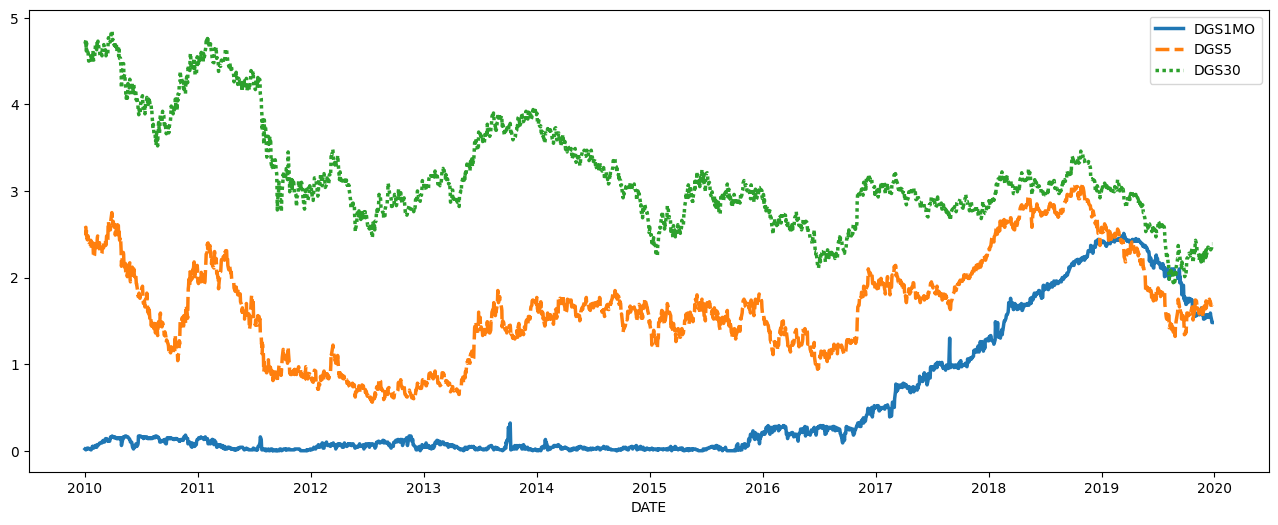

In [104]:
Y = tsy_data[['DGS1MO', 'DGS5', 'DGS30']].shift(-5)
plt.figure(figsize=(16, 6))
sns.lineplot(data=Y, palette="tab10", linewidth=2.5)

Text(0, 0.5, 'Taxa de Juros (%)')

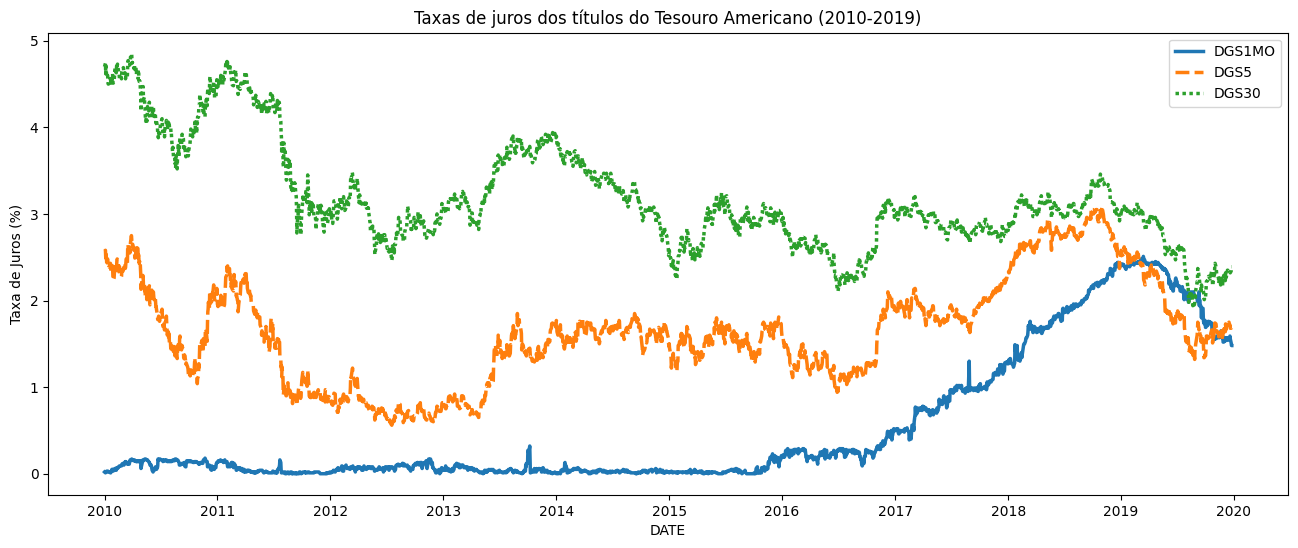

In [105]:
subset_Y = Y.loc[
    (Y.index.year >= 2010) & (Y.index.year < 2020),
]
plt.figure(figsize=(16, 6))
sns.lineplot(data=subset_Y, palette="tab10", linewidth=2.5)
plt.title('Taxas de juros dos títulos do Tesouro Americano (2010-2019)')
plt.ylabel('Taxa de Juros (%)')

> Vemos que taxa de longo prazo caiu me a de curto prazo subiu

In [106]:
X = tsy_data.drop(columns=['DGS1MO', 'DGS5', 'DGS30'])

In [107]:
dataset = pd.concat([X, Y], axis=1).dropna()

In [108]:
dataset.shape

(2519, 17)

<Axes: >

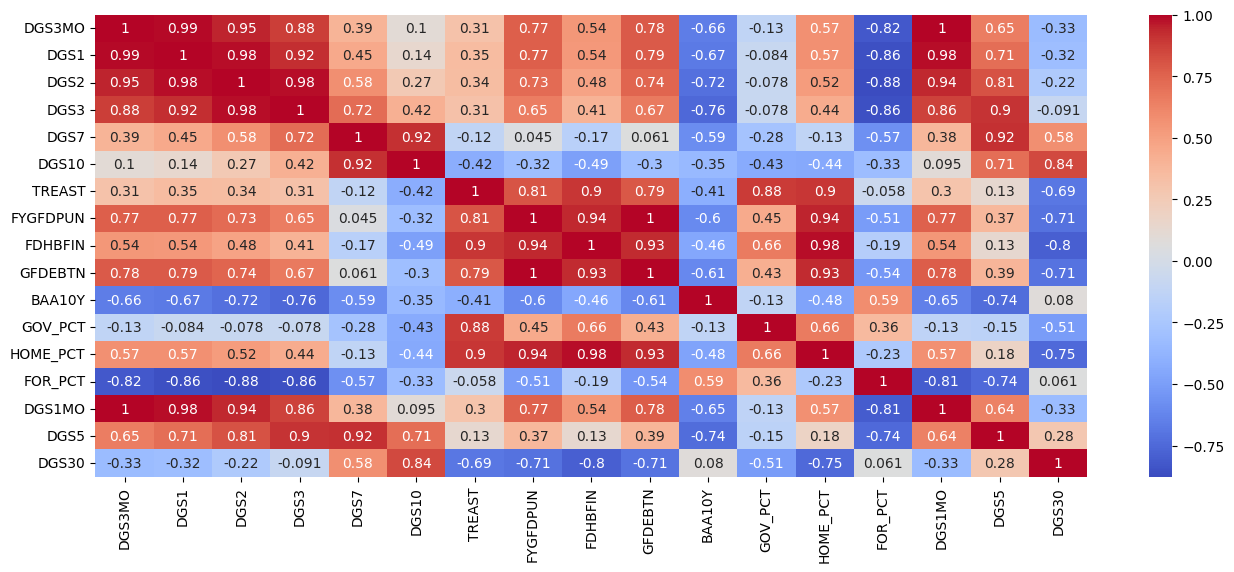

In [109]:
plt.figure(figsize=(16, 6))
sns.heatmap(dataset.corr(), annot=True, cmap='coolwarm')

In [110]:
train_size = int(len(dataset) * 0.8)
X = dataset.drop(columns=['DGS1MO', 'DGS5', 'DGS30'])
Y = dataset[['DGS1MO', 'DGS5', 'DGS30']]
xtrain, xtest = X[0:train_size].values, X[train_size:len(X)].values
ytrain, ytest = Y[0:train_size].values, Y[train_size:len(Y)].values

In [111]:
xtrain.shape, xtest.shape, ytrain.shape, ytest.shape

((2015, 14), (504, 14), (2015, 3), (504, 3))

Nessa caso de estudo o principal objetivo é comparar os modelos lineares com a rede neural artificial na modelagem da yield curve. Dessa forma, usaremos, RL, LASSO, EN E A Rede neural no keras

In [112]:
names = []
kfold_result = []
test_result = []
train_result = []

In [113]:
models = [
    ('LR', LinearRegression()),
    ('LASSO', Lasso()),
    ('EN', ElasticNet()),
    ('CART', DecisionTreeRegressor()),
    ('KNN', KNeighborsRegressor()),
    ('MLP', MLPRegressor()),
]

In [114]:
import warnings
warnings.filterwarnings('ignore')
def evaluate_model(name, model):
    global names, kfold_result, test_result, train_result
    

    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    
    cv_results = -1 * cross_val_score(model, xtrain, ytrain, cv=kfold, scoring='neg_mean_squared_error')
    
    # Treina o modelo
    res = model.fit(xtrain, ytrain)
    
    
    pred_test = res.predict(xtest)
    pred_train =res.predict(xtrain)
    mse_test = mean_squared_error(ytest, pred_test)
    mse_train = mean_squared_error(ytrain, pred_train)
    
    names.append(name)
    kfold_result.append(cv_results)
    test_result.append(mse_test)
    train_result.append(mse_train)

In [115]:
kfold_result = [ np.mean(i) for i in kfold_result]

In [116]:
from concurrent.futures import ThreadPoolExecutor, wait, ALL_COMPLETED

In [117]:
with ThreadPoolExecutor(max_workers=4) as executor:
    futures = [executor.submit(evaluate_model, name, model) for name, model in models]


    # Aguarda a conclusão das tarefas
    done, not_done = wait(futures, timeout=600, return_when=ALL_COMPLETED)
    # Cancela 
    for f in not_done:
        f.cancel()

RNA

In [118]:
def model_():
    model = keras.models.Sequential([
        keras.layers.Dense(64, activation=keras.activations.elu, kernel_initializer='he_normal'),
        keras.layers.Dense(32, activation=keras.activations.elu, kernel_initializer='he_normal'),
        keras.layers.Dense(8, activation=keras.activations.elu, kernel_initializer='he_normal'),
        keras.layers.Dense(3)
    ])
    return model

In [119]:
model = model_()

In [120]:
model.compile(
    optimizer=keras.optimizers.RMSprop(momentum=0.9),
    loss='mean_squared_error',
    metrics=['mean_squared_error']
)

history = model.fit(
    xtrain,
    ytrain,
    epochs=50,
    verbose=0,
    shuffle=False
)

<Axes: >

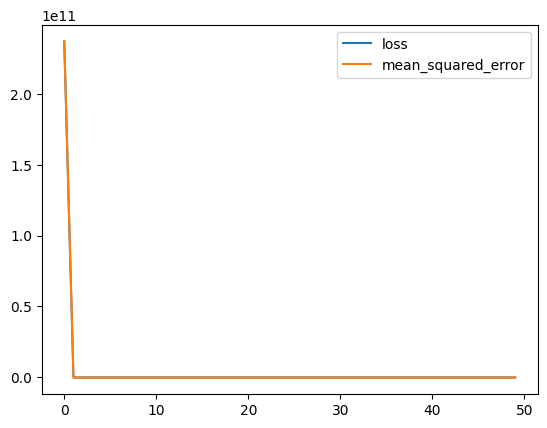

In [121]:
pd.DataFrame(history.history).plot()

In [122]:
pred_train = model.predict(xtrain)
pred_test = model.predict(xtest)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [123]:
train_result.append(mean_squared_error(ytrain, pred_train))
test_result.append(mean_squared_error(ytest, pred_test))

In [124]:
names.append('NN')

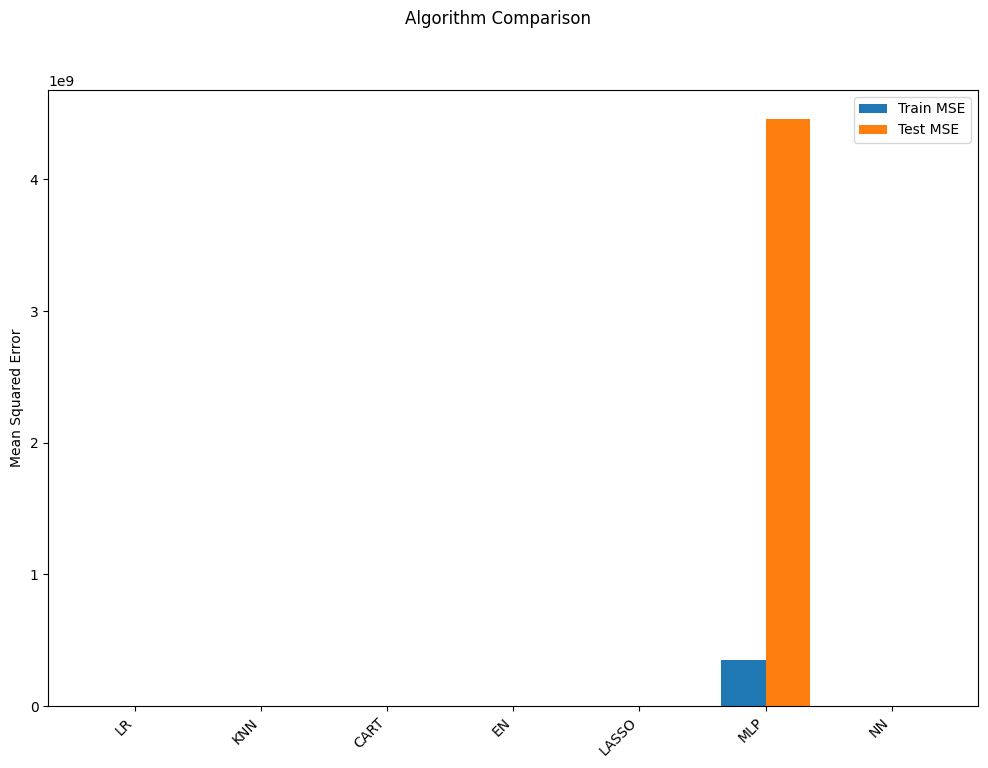

In [125]:
fig = plt.figure(figsize=(12,8))
fig.suptitle('Algorithm Comparison')
ind= np.arange(len(names)) # as posições das barras
width = 0.35 # a largura das barras

plt.bar(ind - width/2, train_result, width, label='Train MSE')
plt.bar(ind + width/2, test_result, width, label='Test MSE')
plt.ylabel('Mean Squared Error')
plt.xticks(ind, names, rotation=45, ha='right')
plt.legend()
plt.show()

MLP

In [126]:
mlp = MLPRegressor()
params = {
        'hidden_layer_sizes': [(50, 50), (50,), (20, 30, 20)],
        'activation': ['relu', 'logistic'],
        'alpha': [0.0001],
        'learning_rate': ['adaptive'],
    }

In [127]:
from sklearn.model_selection import RandomizedSearchCV

In [128]:
hgs = RandomizedSearchCV(
    mlp,
    params,
    n_iter=4,
    verbose=1,
)
hgs.fit(xtrain, ytrain)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


,estimator,MLPRegressor()
,param_distributions,"{'activation': ['relu', 'logistic'], 'alpha': [0.0001], 'hidden_layer_sizes': [(50, ...), (50,), ...], 'learning_rate': ['adaptive']}"
,n_iter,4
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [129]:
hgs.best_params_, hgs.best_score_

({'learning_rate': 'adaptive',
  'hidden_layer_sizes': (20, 30, 20),
  'alpha': 0.0001,
  'activation': 'logistic'},
 np.float64(-8.790839921514257))

In [130]:
MODEL = MLPRegressor(hidden_layer_sizes=(20, 30, 20))

In [131]:
MODEL.fit(xtrain, ytrain)

,loss,'squared_error'
,hidden_layer_sizes,"(20, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,200
,shuffle,True


In [132]:
pred = MODEL.predict(xtest)

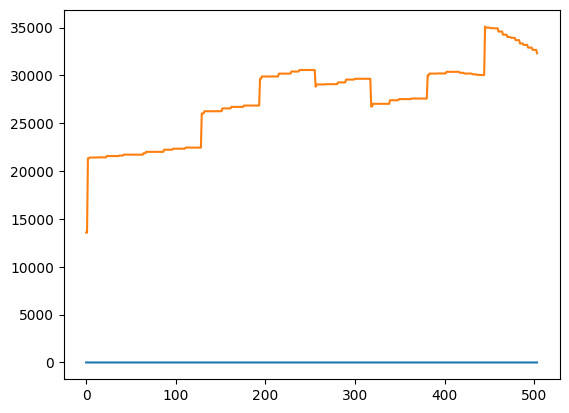

In [133]:
plt.plot(ytest[:,0])
plt.plot(pred[:,0])

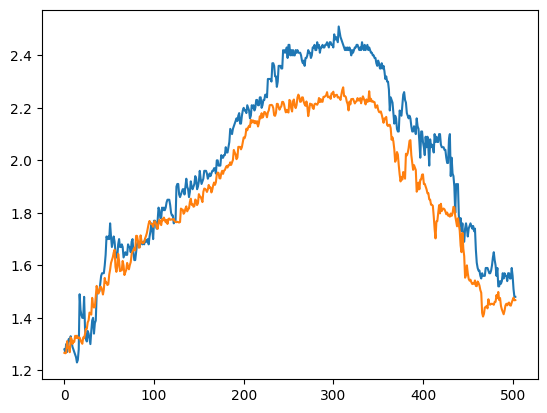

In [134]:
pred = LinearRegression().fit(xtrain, ytrain).predict(xtest)

plt.plot(ytest[:,0])
plt.plot(pred[:,0])

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


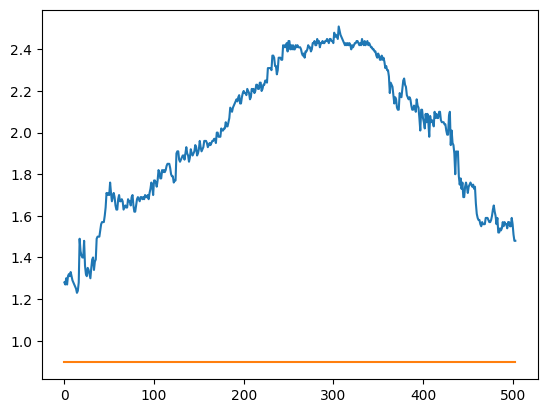

In [135]:
pred = model.predict(xtest)

plt.plot(ytest[:,0])
plt.plot(pred[:,0])

Usando arima


In [136]:
arima_1 = sm.tsa.ARIMA(ytrain[:, 0], exog=xtrain)

In [137]:
arima_1_fit  =arima_1.fit()

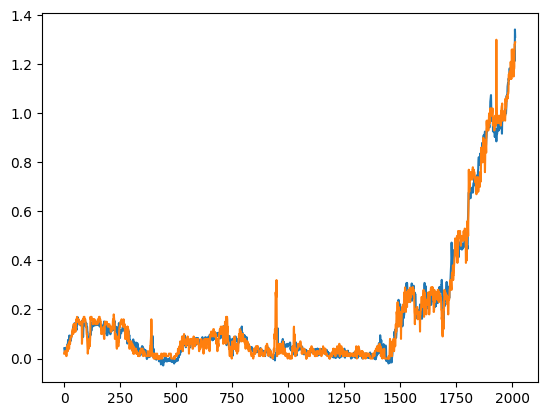

In [138]:
plt.plot(arima_1_fit.fittedvalues.tolist())
plt.plot(ytrain[:, 0].tolist())
plt.show()

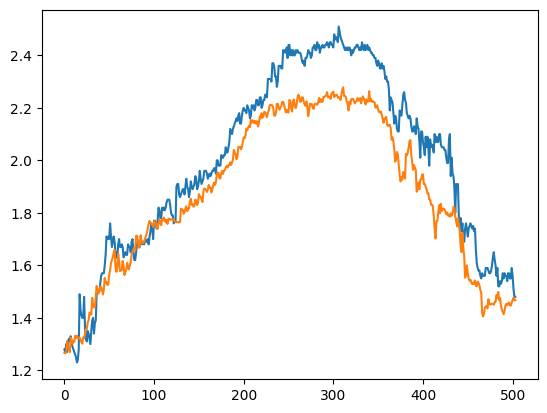

In [ ]:
pred = arima_1_fit.predict(start=len(ytrain), end=len(ytrain)+len(ytest)-1, exog=xtest)

plt.plot(ytest[:,0])
plt.plot(pred)



* **Definir o `return_period`** como quiser (5 dias, 10 dias, 1 mês etc.);
* **Escolher se vai usar ou não o `iloc`** (pegar todos os pontos ou só alguns);
* **Trocar o `iloc` por `resample`** se seu índice for temporal (`DatetimeIndex`), assim você controla a frequência (diária, semanal, mensal).
